<a href="https://colab.research.google.com/github/fadeeva/normal_projects/blob/master/Loan%20Prediction%20Problem/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
import kagglehub

path = kagglehub.dataset_download('altruistdelhite04/loan-prediction-problem-dataset')

print('Path to dataset files:', path)

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.
Path to dataset files: /kaggle/input/loan-prediction-problem-dataset


In [ ]:
! ls {path}

test_Y3wMUE5_7gLdaTN.csv  train_u6lujuX_CVtuZ9i.csv


In [6]:
df = pd.read_csv(f'{path}/train_u6lujuX_CVtuZ9i.csv')
df.drop('Loan_ID', axis=1, inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
df.shape

(614, 12)

In [23]:
df['Credit_History'].fillna(0, inplace=True)
df['Credit_History'] = df['Credit_History'].astype('int')

In [25]:
missing_df = pd.DataFrame({
    'col': df.columns,
    'type': df.dtypes.values,
    'missing vals': df.isnull().sum().values,
    '% missing vals': (df.isnull().sum() / len(df)*100).values
})

missing_df

,col,type,missing vals,% missing vals
0,Gender,object,13,2.117264
1,Married,object,3,0.488599
2,Dependents,object,15,2.442997
3,Education,object,0,0.000000
4,Self_Employed,object,32,5.211726
5,ApplicantIncome,int64,0,0.000000
6,CoapplicantIncome,float64,0,0.000000
7,LoanAmount,float64,22,3.583062
8,Loan_Amount_Term,float64,14,2.280130
9,Credit_History,int64,0,0.000000


In [26]:
missing_df['missing vals'].sum()

np.int64(99)

In [27]:
missing_dict = {}

for col in df.columns:
    missing_by_target = df[df[col].isnull()].groupby('Loan_Status').size()
    missing_dict[col] = missing_by_target

result_df = pd.DataFrame(missing_dict).fillna(0).astype(int)
result_df.T

Loan_Status,N,Y
Gender,5,8
Married,0,3
Dependents,6,9
Education,0,0
Self_Employed,9,23
ApplicantIncome,0,0
CoapplicantIncome,0,0
LoanAmount,11,11
Loan_Amount_Term,6,8
Credit_History,0,0


In [11]:
result_df.T[['N', 'Y']].sum()

,0
Loan_Status,
N,50
Y,99


In [ ]:
df.value_counts('Gender')

,count
Gender,
Male,489
Female,112


In [ ]:
df.groupby(['Gender', 'Loan_Status']).count()['Loan_ID']

Gender  Loan_Status
Female  N               37
        Y               75
Male    N              150
        Y              339
Name: Loan_ID, dtype: int64

In [ ]:
df.groupby(['Gender', 'Loan_Status', 'Married', 'Education']).count()['Loan_ID']

Gender  Loan_Status  Married  Education   
Female  N            No       Graduate         24
                              Not Graduate      5
                     Yes      Graduate          7
                              Not Graduate      1
        Y            No       Graduate         42
                              Not Graduate      9
                     Yes      Graduate         18
                              Not Graduate      5
Male    N            No       Graduate         37
                              Not Graduate     12
                     Yes      Graduate         68
                              Not Graduate     33
        Y            No       Graduate         62
                              Not Graduate     19
                     Yes      Graduate        207
                              Not Graduate     49
Name: Loan_ID, dtype: int64

In [ ]:
df['ApplicantIncome'].describe()

,ApplicantIncome
count,614.000000
mean,5403.459283
std,6109.041673
min,150.000000
25%,2877.500000
50%,3812.500000
75%,5795.000000
max,81000.000000


In [52]:
numerical_columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
df[numerical_columns].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount
count,614.000000,614.000000,592.000000
mean,5403.459283,1621.245798,146.412162
std,6109.041673,2926.248369,85.587325
min,150.000000,0.000000,9.000000
25%,2877.500000,0.000000,100.000000
50%,3812.500000,1188.500000,128.000000
75%,5795.000000,2297.250000,168.000000
max,81000.000000,41667.000000,700.000000


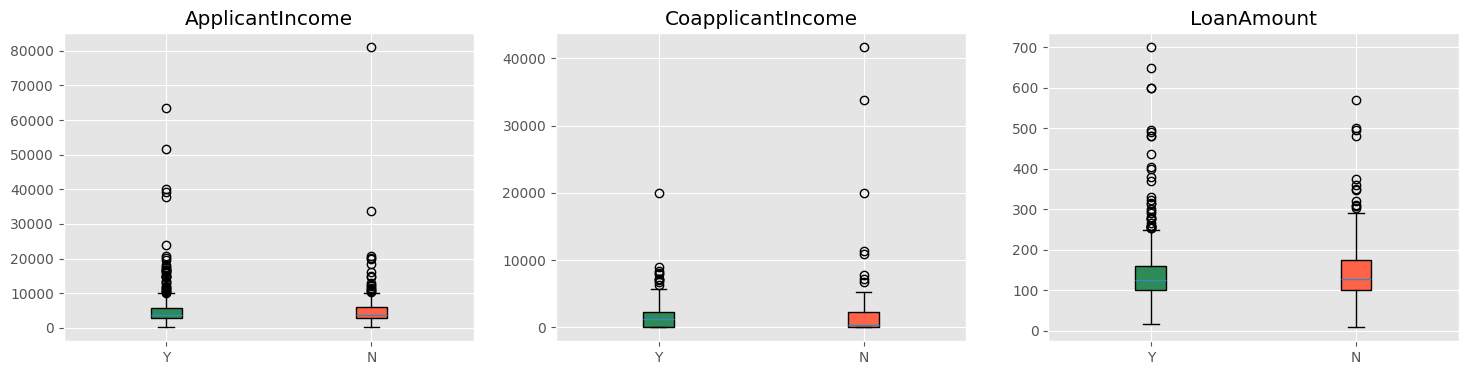

In [79]:
labels = ['Y', 'N']
y = df[df['Loan_Status']=='Y']
n = df[df['Loan_Status']=='N']

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

for i, col in enumerate(numerical_columns):
    bplot = ax[i].boxplot([y[col].dropna(), n[col].dropna()], tick_labels=labels, patch_artist=True)
    for patch, color in zip(bplot['boxes'], ['seagreen', 'tomato']):
        patch.set_facecolor(color)
    ax[i].set_title(col)
